In [6]:
from dotenv import load_dotenv
import os
load_dotenv()
from langchain_openai import ChatOpenAI

In [11]:
openai_key = os.getenv("OPENAI_API_KEY")

llm = ChatOpenAI(
    model="gpt-4o",
    api_key=openai_key,
    temperature=0.2,
    max_tokens=None,
    max_retries=2
)

In [13]:
response = llm.invoke("Why did Trump attack Iran")
print("Response: ", response.content)

Response:  As of my last update in October 2023, there has been no verified report of former President Donald Trump launching a military attack on Iran. However, tensions between the United States and Iran have been high for many years, particularly during Trump's presidency from 2017 to 2021. These tensions were marked by events such as the U.S. withdrawal from the Iran nuclear deal in 2018 and the assassination of Iranian General Qasem Soleimani in January 2020.

If there have been any recent developments or specific incidents involving Trump and Iran after October 2023, I would not have that information. For the most current and accurate news, I recommend checking reliable news sources.


In [14]:
topic = {
    "name": "Git Branching",
    "notes": "Branches allow parallel develoipment of features" 
}


In [15]:
question_prompt = f"""
You are an teacher whose job is to prepare a conceptual question on a topic using the notes provided to you.
Topic: {topic["name"]}
Notes: {topic["notes"]}
"""

In [16]:
question_prompt

'\nYou are an teacher whose job is to prepare a conceptual question on a topic using the notes provided to you.\nTopic: Git Branching\nNotes: Branches allow parallel develoipment of features\n'

In [17]:
from typing import TypedDict, List
class QuizState(TypedDict):
    messages: List
    quiz: {"topic": str, "notes": str, "question": str}
    user_answer: str
    understanding: str
    hint: str
    attempts: int
    

In [18]:
quiz_state: QuizState = {
    "quiz": {"topic": topic["name"], "notes": topic["notes"], "question": ""},
    "user_answer": "",
    "hint": "",
    "understanding": "NA",
    "attempts": 0,
    "messages": [],
}

In [21]:
def ai_gen_question(state: QuizState) -> QuizState:
    question_prompt = f"""
You are an examiner whose job is to prepare a conceptual question on a topic using the notes provided to you.
Topic: {state["quiz"]["topic"]}
Notes: {state["quiz"]["notes"]}
Keep the question simple, just to test a basic understanding.
"""
    question = llm.invoke(question_prompt).content
    state["quiz"]["question"] = question
    state["messages"].append({"role": "AI generation", "message": question})
    return state
    

In [22]:
ai_quiz = ai_gen_question(quiz_state)

In [23]:
ai_quiz

{'quiz': {'topic': 'Git Branching',
  'notes': 'Branches allow parallel develoipment of features',
  'question': 'Question: Explain how branching in Git facilitates parallel development of features in a project.'},
 'user_answer': '',
 'hint': '',
 'understanding': 'NA',
 'attempts': 0,
 'messages': [{'role': 'AI generation',
   'message': 'Question: Explain how branching in Git facilitates parallel development of features in a project.'}]}

In [25]:
def ask_user(state: QuizState) -> QuizState:
    """
    Ask the user the AI generated quiz.
    """
    question = state["messages"][-1]["message"]
    user_reply = input(question)
    state["attempts"] += 1
    state["messages"].append({"role": "User", "message": user_reply})
    return state

In [27]:
user_answer = ask_user(quiz_state)

developers can work on feature branches parallely which can be later merged to the main branch developers can work on feature branches parallely which can be later merged to the main branch 


In [29]:
quiz_state

{'quiz': {'topic': 'Git Branching',
  'notes': 'Branches allow parallel develoipment of features',
  'question': 'Question: Explain how branching in Git facilitates parallel development of features in a project.'},
 'user_answer': '',
 'hint': '',
 'understanding': 'NA',
 'attempts': 2,
 'messages': [{'role': 'AI generation',
   'message': 'Question: Explain how branching in Git facilitates parallel development of features in a project.'},
  {'role': 'User',
   'message': 'developers can work on feature branches parallely which can be later merged to the main branch'},
  {'role': 'User',
   'message': 'developers can work on feature branches parallely which can be later merged to the main branch '}]}

In [37]:
def evaluate(state: QuizState) -> str:
    """
    Evaluate the user reply, using LLM.
    Returns correct, retry or limits reached outputs
    """
    ai_prompt = f"""
        You have to analyze the user's reply to a question to check the understanding of a concept and tell whether
        it is acceptable using notes provided to you.
        Return: correct or incorrect, along with some explanation. Also if answer is incorrect, give the correct answer based on notes
        in a friendly.
        Output sample -> Correct: You have correctly understood use git branch in helping parallel feature development.
                        
        Quiz: {state["quiz"]["question"]}
        Notes: {state["quiz"]["notes"]}
        User's reply: {state["messages"][-1]["message"]}
    """
    evaluation = llm.invoke(ai_prompt).content.lower()
    print("Evaluation: ", evaluation)
    state["messages"].append({"role": "AI evaluation", "message": evaluation})
    if "incorrect" in evaluation:
       if state["attempts"] <=1:
          return "retry"
       return "limit_reached" 
    return "correct"
    

In [33]:
evaluation = evaluate(quiz_state)

Evaluation:  correct: you have correctly understood how branching in git facilitates parallel development of features. developers can indeed work on feature branches in parallel, and these branches can later be merged into the main branch, allowing for simultaneous progress on different features without interfering with each other.


In [34]:
evaluation

'correct'

In [36]:
# git_state["messages"].pop()
quiz_state

{'quiz': {'topic': 'Git Branching',
  'notes': 'Branches allow parallel develoipment of features',
  'question': 'Question: Explain how branching in Git facilitates parallel development of features in a project.'},
 'user_answer': '',
 'hint': '',
 'understanding': 'NA',
 'attempts': 2,
 'messages': [{'role': 'AI generation',
   'message': 'Question: Explain how branching in Git facilitates parallel development of features in a project.'},
  {'role': 'User',
   'message': 'developers can work on feature branches parallely which can be later merged to the main branch'},
  {'role': 'User',
   'message': 'developers can work on feature branches parallely which can be later merged to the main branch '},
  {'role': 'AI evaluation',
   'message': 'correct: you have correctly understood how branching in git facilitates parallel development of features. developers can indeed work on feature branches in parallel, and these branches can later be merged into the main branch, allowing for simultan

In [38]:
def give_hint(state: QuizState) -> QuizState:
    ai_prompt = f"""
    Provide a hint to a quiz, without telling the complete answer.
    You are provided notes for generating a hint.
    quiz: {state["quiz"]["question"]}
    notes: {state["quiz"]["notes"]}
    user's reply: {state["messages"][-2]["message"]}
    """
    hint = llm.invoke(ai_prompt)
    state["messages"].append({"role": "AI help", "message": hint.content})
    return state

In [39]:
hint = give_hint(quiz_state)

In [40]:
quiz_state

{'quiz': {'topic': 'Git Branching',
  'notes': 'Branches allow parallel develoipment of features',
  'question': 'Question: Explain how branching in Git facilitates parallel development of features in a project.'},
 'user_answer': '',
 'hint': '',
 'understanding': 'NA',
 'attempts': 2,
 'messages': [{'role': 'AI generation',
   'message': 'Question: Explain how branching in Git facilitates parallel development of features in a project.'},
  {'role': 'User',
   'message': 'developers can work on feature branches parallely which can be later merged to the main branch'},
  {'role': 'User',
   'message': 'developers can work on feature branches parallely which can be later merged to the main branch '},
  {'role': 'AI evaluation',
   'message': 'correct: you have correctly understood how branching in git facilitates parallel development of features. developers can indeed work on feature branches in parallel, and these branches can later be merged into the main branch, allowing for simultan

In [41]:
from langgraph.graph import StateGraph, END

builder = StateGraph(QuizState)

builder.add_node("generate_quiz", ai_gen_question)
builder.add_node("ask_user", ask_user)
builder.add_node("give_hint", give_hint)

builder.set_entry_point("generate_quiz")
builder.add_edge("generate_quiz", "ask_user")
builder.add_conditional_edges(
    "ask_user",
    evaluate,
    {
        "correct": END,
        "retry": "give_hint",
        "limit_reached": END
    }
)
builder.add_edge("give_hint", "ask_user")


In [42]:
graph = builder.compile()

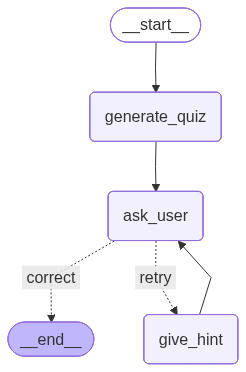

In [43]:
graph

In [47]:
quiz_state: QuizState = {
    "quiz": {"topic": topic["name"], "notes": topic["notes"], "question": ""},
    "user_answer": "",
    "hint": "",
    "understanding": "NA",
    "attempts": 0,
    "messages": [],
}

In [48]:
workflow = graph.invoke(quiz_state)

Question: Explain how branching in Git facilitates parallel development of features in a project. Something to do with hopw the world ends


Evaluation:  incorrect: the user's reply does not address the concept of branching in git or how it facilitates parallel development of features in a project. the response is unrelated to the topic and does not demonstrate an understanding of the concept.


Think about how different paths can be taken simultaneously without interfering with each other, allowing multiple changes to be developed and tested independently. Star wars


Evaluation:  incorrect: the user's reply "star wars" does not address the concept of branching in git or how it facilitates parallel development of features in a project. the reply is unrelated to the topic and does not demonstrate an understanding of the concept as outlined in the notes.


In [46]:
workflow["messages"]

[{'role': 'AI generation',
  'message': 'Question: Explain how branching in Git facilitates parallel development of features in a project.'},
 {'role': 'User', 'message': 'It has to do with World War 3, I guess'},
 {'role': 'AI evaluation',
  'message': 'incorrect: your response does not address the concept of branching in git or how it facilitates parallel development of features in a project. branching in git allows developers to work on different features or bug fixes simultaneously without interfering with the main codebase, which is essential for parallel development.'},
 {'role': 'AI',
  'message': "Hint: Think about how different team members can work on separate tasks simultaneously without interfering with each other's progress."},
 {'role': 'User',
  'message': 'It allows parallel development as developers can work on separate feature branches without affecting the main branch. These branches could noter be merged after evaluation to the main branchmain '},
 {'role': 'AI eval

In [70]:
topics = [{
    "name": "Small Business Defined",
    "notes": f"""Small businesses are often the starting point for entrepreneurs as they develop their ideas and build a customer base. 
    The Small Business Administration (SBA) defines a small business as a for-profit entity with fewer than 500 employees. This definition makes
    these businesses eligible for various government programs and preferences. Small businesses play a crucial role in our economy and communities."""
    },
    {
    "name": "Small Business Impact",
    "notes": f"""There are over 33.2 million small businesses in the United States, making up 99.9% of all firms. From 1995 to 2021, small businesses created 
    17.3 million net new jobs, significantly more than large businesses. Despite challenges like the COVID-19 recession, small businesses rebounded quickly,
    demonstrating their resilience and importance to economic recovery. They contribute to local economies by reinvesting paychecks and taxes, supporting 
    new businesses, and improving
    public services. On average, small businesses offer competitive wages, averaging $30.42 per hour, translating to an annual income of $63,000."""
    },
    {
    "name": "Small Business Demographics",
    "notes": f"""43.4% of small businesses are owned by females, reflecting progress toward gender equality in entrepreneurship.
    20.4% are owned by racial minorities, including 14.5% by Hispanics.
    6.1% are owned by veterans, contributing diverse perspectives to the U.S. economy.
    Hispanic-owned businesses, for example, pay over $100 billion annually in payroll to their 1 million workers."""
    }
    ]

In [155]:
class QuizSate(TypedDict):
    topic: str
    notes: str
    question: str
    messages: List
    attempts: int
    

In [156]:
class DialoguesState(TypedDict):
    index: int
    topics: List
    messages: List
    quiz: QuizState
    

In [157]:
dialogues: DialoguesState = {
    "index": -1,
    "topics": topics,
    "messages": [],
    "quiz": {"topic": "", 
             "notes": "",
             "question": "",
             "messages": [],
             "attempts": 0
            }
}

In [158]:
def set_next_index(dialogues: DialoguesState) -> DialoguesState:
    dialogues["index"] += 1
    return dialogues["index"]

In [159]:
set_next_index(dialogues)

0

In [160]:
def check_termination(ind: int) -> bool:
    return ind >= len(topics)

In [163]:
check_termination(1)

False

In [164]:
def setup_dialogue(dialogues: DialoguesState) -> QuizState:
    topic = dialogues["topics"][dialogues["index"]]
    new_dialogue: QuizState = {
        "name": topic["name"], 
        "notes": topic["notes"], 
        "question": "",
        "messages": [],
        "attempts": 0
    }
    dialogues["quiz"] = new_dialogue
    return dialogues

In [168]:
dialogues = setup_dialogue(dialogues)

In [166]:
def ai_gen_question(state: DialoguesState) -> DialoguesState:
    question_prompt = f"""
    You are an examiner whose job is to prepare a conceptual question on a topic using the notes provided to you.
    Topic: {state["quiz"]["name"]}
    Notes: {state["quiz"]["notes"]}
    Keep the question simple, just to test a basic understanding.
    """
    question = llm.invoke(question_prompt).content
    state["quiz"]["question"] = question
    state["quiz"]["messages"].append({"role": "AI generation", "message": question})
    return state
    

In [169]:
ai_gen_question(dialogues)

{'index': 0,
 'topics': [{'name': 'Small Business Defined',
   'notes': 'Small businesses are often the starting point for entrepreneurs as they develop their ideas and build a customer base. \n    The Small Business Administration (SBA) defines a small business as a for-profit entity with fewer than 500 employees. This definition makes\n    these businesses eligible for various government programs and preferences. Small businesses play a crucial role in our economy and communities.',
   'question': 'What is the definition of a small business according to the Small Business Administration (SBA), and why is this definition significant for entrepreneurs?'},
  {'name': 'Small Business Impact',
   'notes': 'There are over 33.2 million small businesses in the United States, making up 99.9% of all firms. From 1995 to 2021, small businesses created \n    17.3 million net new jobs, significantly more than large businesses. Despite challenges like the COVID-19 recession, small businesses reboun

In [170]:
def ask_user(state: DialoguesState) -> DialoguesState:
    """
    Ask the user an AI generated quiz
    """
    question = state["quiz"]["question"]
    user_reply = input(question)
    state["quiz"]["attempts"] += 1
    state["quiz"]["messages"].append({"role": "User", "message": user_reply})
    return state

In [172]:
ask_user(dialogues)

What is the definition of a small business according to the Small Business Administration (SBA), and why is this definition significant for entrepreneurs? It is yellow in color


{'index': 0,
 'topics': [{'name': 'Small Business Defined',
   'notes': 'Small businesses are often the starting point for entrepreneurs as they develop their ideas and build a customer base. \n    The Small Business Administration (SBA) defines a small business as a for-profit entity with fewer than 500 employees. This definition makes\n    these businesses eligible for various government programs and preferences. Small businesses play a crucial role in our economy and communities.',
   'question': 'What is the definition of a small business according to the Small Business Administration (SBA), and why is this definition significant for entrepreneurs?'},
  {'name': 'Small Business Impact',
   'notes': 'There are over 33.2 million small businesses in the United States, making up 99.9% of all firms. From 1995 to 2021, small businesses created \n    17.3 million net new jobs, significantly more than large businesses. Despite challenges like the COVID-19 recession, small businesses reboun

In [173]:
def evaluate(state: DialoguesState) -> str:
    """
    Evaluate the user reply, using LLM.
    Returns correct, retry or limits reached outputs
    """
    ai_prompt = f"""
        You have to analyze the user's reply to a question to check the understanding of a concept and tell whether
        it is acceptable using notes provided to you. Do not give the correct answer.
        Return: correct or incorrect, along with some comment on the users answer. 
        Output sample -> Correct: You have correctly understood use git branch in helping parallel feature development.
                        
        Quiz: {state["quiz"]["question"]}
        Notes: {state["quiz"]["notes"]}
        User's reply: {state["quiz"]["messages"][-1]["message"]}
    """
    evaluation = llm.invoke(ai_prompt).content.lower()
    state["quiz"]["messages"].append({"role": "AI evaluation", "message": evaluation})
    if "incorrect" in evaluation:
       if state["quiz"]["attempts"] <=1:
           
          return "retry"
       state["quiz"]["messages"].append({"role": "System", "message": f"Sorry, your answer does not meet expectations. Expected: {state["quiz"]["notes"]}"})
       return "limit_reached" 
    return "correct"
    

In [174]:
evaluate(dialogues)

Evaluation:  incorrect: your response does not address the definition of a small business according to the small business administration (sba) or its significance for entrepreneurs.


'retry'

In [175]:
dialogues

{'index': 0,
 'topics': [{'name': 'Small Business Defined',
   'notes': 'Small businesses are often the starting point for entrepreneurs as they develop their ideas and build a customer base. \n    The Small Business Administration (SBA) defines a small business as a for-profit entity with fewer than 500 employees. This definition makes\n    these businesses eligible for various government programs and preferences. Small businesses play a crucial role in our economy and communities.',
   'question': 'What is the definition of a small business according to the Small Business Administration (SBA), and why is this definition significant for entrepreneurs?'},
  {'name': 'Small Business Impact',
   'notes': 'There are over 33.2 million small businesses in the United States, making up 99.9% of all firms. From 1995 to 2021, small businesses created \n    17.3 million net new jobs, significantly more than large businesses. Despite challenges like the COVID-19 recession, small businesses reboun

In [184]:
def give_hint(state: DialoguesState) -> DialoguesState:
    ai_prompt = f"""
    Provide a hint to a quiz, without telling the complete answer.
    You are provided notes for generating a hint.
    quiz: {state["quiz"]["question"]}
    notes: {state["quiz"]["notes"]}
    user's reply: {state["quiz"]["messages"][-2]["message"]}
    """
    hint = llm.invoke(ai_prompt)
    state["quiz"]["messages"].append({"role": "AI hint", "message": hint.content})
    return state

In [ ]:
give_hint(dialogues)

In [186]:
dialogues["quiz"]["messages"].pop()
# dialogues["messages"] = []

{'role': 'AI hint',
 'message': 'Hint: Consider the criteria set by the Small Business Administration (SBA) regarding the number of employees that classify a business as "small." This classification is crucial because it opens doors to specific government programs and support that can be pivotal for entrepreneurs starting their journey.'}

In [187]:
dialogues

{'index': 0,
 'topics': [{'name': 'Small Business Defined',
   'notes': 'Small businesses are often the starting point for entrepreneurs as they develop their ideas and build a customer base. \n    The Small Business Administration (SBA) defines a small business as a for-profit entity with fewer than 500 employees. This definition makes\n    these businesses eligible for various government programs and preferences. Small businesses play a crucial role in our economy and communities.',
   'question': 'What is the definition of a small business according to the Small Business Administration (SBA), and why is this definition significant for entrepreneurs?'},
  {'name': 'Small Business Impact',
   'notes': 'There are over 33.2 million small businesses in the United States, making up 99.9% of all firms. From 1995 to 2021, small businesses created \n    17.3 million net new jobs, significantly more than large businesses. Despite challenges like the COVID-19 recession, small businesses reboun

In [87]:

from langgraph.graph import StateGraph, END

builder = StateGraph(DialoguesState)

builder.add_node("set_next_index", set_next_index)
builder.add_node("start_dialogue", start_dialogue)
builder.add_conditional_edges(
    "set_next_index",
    check_termination,
    {
        True: END,
        False: "start_dialogue"
    }
)

builder.add_node("generate_quiz", ai_gen_question)
builder.add_node("ask_user", ask_user)
builder.add_node("give_hint", give_hint)

builder.set_entry_point("generate_quiz")
builder.add_edge("generate_quiz", "ask_user")
builder.add_conditional_edges(
    "ask_user",
    evaluate,
    {
        "correct": "set_next_index",
        "retry": "give_hint",
        "limit_reached": "set_next_index"
    }
)
builder.add_edge("give_hint", "ask_user")
builder.set_entry_point("set_next_index")




In [88]:
graph = builder.compile()

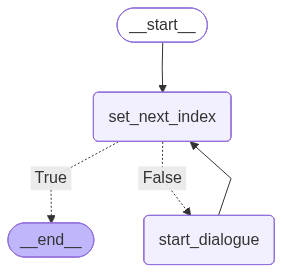

In [89]:
graph

In [ ]:
def generate_quiz(topic: TopicState) -> TopicState:
    question_prompt = f"""
    You are an examiner whose job is to prepare a conceptual question on a topic using the notes provided to you.
    Topic: {topic["topic"]["name"]}
    Notes: {state["quiz"]["notes"]}
    Keep the question simple, just to test a basic understanding.
    """
    question = llm.invoke(question_prompt).content
    state["quiz"]["question"] = question
    state["messages"].append({"role": "AI quiz generator", "message": question})
    return state
    
    